# Performing Domain Analysis with AI  
## Leveraga SA Model, Write Up, and Results on Strategy to develop a first cut Architecture

First we load up the PEAK Model

### Model-Specific Code (Do Not Modify)

This section contains code that is specific to the system model. It is updated only when the model is changed and should not require user modifications under normal circumstances.

If a new model is introduced, ensure this section is reviewed and updated as needed.


In [1]:
#!pip install --upgrade git+https://github.com/tkSDISW/Capella_Tools 
import capellambse.decl

from capella_tools import capellambse_helper

from IPython import display as diag_display
resources = {
    "PEAK": "PEAK/PEAK",
}
path_to_model = "../PEAK.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)
from capella_tools import Pub4C
# Instantiate the class with the traceability file
traceability_store = Pub4C.Traceability_Store("../PEAK/traceability")


## 🔄 Embedding Generation Process

Next we load evaluate whether we ne to update the embedings. If there older than model we will update thems. 🚀


In [2]:

from capella_tools  import capella_embeddings_manager

# Generate embeddings for all objects
model_embedding_manager = capella_embeddings_manager.EmbeddingManager()

embedding_file = "embeddings.json" 
model_embedding_manager.set_files( path_to_model , embedding_file)

model_embedding_manager.create_model_embeddings(model)

✅ EmbeddingManager initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: https://api.openai.com/v1
🤖 Model: gpt-4o
ℹ️ Model file newer than embeddings: ../PEAK.aird
Creating Embeddings
embeddings generated
Saving embeddings


## 🎯 Define the model element or diagram for analysis.

We use the embedding to locate a diagram that will be used for basis of analysis. It a OCB diagrams with relations to all the functional chains. 

> 💡 **Tip:** If you're unsure about the model structure, review the documentation or refer to the model's diagrams for additional guidance.


In [3]:

selected_objects = model_embedding_manager.query_and_select_top_objects("Logical Architecture Storage Container", top_n=1)



This is a list of ranked Objects Based on Query:
Index: 0, Name: Storage Container, Similarity: 0.75, Type: LogicalComponent, Phase: Logical Architecture LA, Source: , Target: 


Generate Diagram 

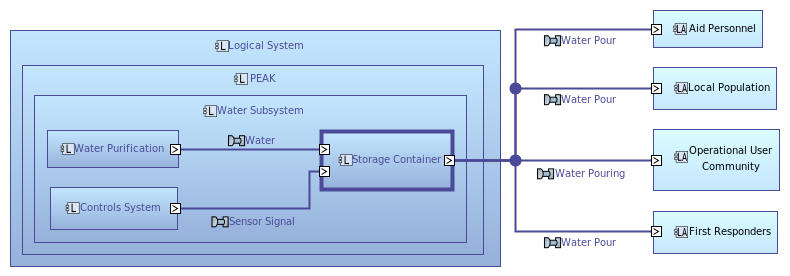

In [4]:
for object in  selected_objects : 
    #print(object)
    if object["type"] == "Diagram" :
        diagram = model.by_uuid(object["uuid"])
        #display(diagram)
    else:
        obj = model.by_uuid(object["uuid"])
        capellambse_helper.display_context_diagram(obj)

In [5]:

selected_objects = model_embedding_manager.query_and_select_top_objects("[LAB] Water Generation - Interface Requirement", top_n=1)



This is a list of ranked Objects Based on Query:
Index: 0, Name: [LAB] Water Generation - Interface Requirement, Similarity: 0.85, Type: Diagram, Phase: Logical Architecture LA, Source: , Target: 


## 📝 Generate Structured Input File 

We then generate the structured input file for all the matching objects and there related objects.
A file "capella_model.yaml" is written it you want to look at it. 

In [6]:
#Workflow
from capella_tools import capellambse_yaml_manager
#import capellambse_yaml_manager
yaml_handler = capellambse_yaml_manager.CapellaYAMLHandler()
   
#Generate YAML for the logical component and append to the file
for object in  selected_objects :  
    yaml_handler.generate_yaml(model.by_uuid(object["uuid"]))  

yaml_handler.generate_traceability_related_objects(model,traceability_store)

#yaml_handler.display()
yaml_handler.generate_yaml_referenced_objects()
#yaml_handler.display()

yaml_handler.write_output_file()


## ⚙️ Execute  Prompt


Execute the prompt that will use the model and system document. 

In [7]:
import os
from openai import OpenAI
from IPython.core.display import HTML
from IPython.display import display, clear_output, Markdown, IFrame
from capella_tools  import Open_AI_RAG_manager


#print(object)
# Step 1: Get YAML content
yaml_content = yaml_handler.get_yaml_content()

# Step 2: Invoke ChatGPT for analysis
analyzer = Open_AI_RAG_manager.ChatGPTAnalyzer(yaml_content)#analyzer.add_text_file_to_messages("PEAK System.docx")
prompt = """
Write a detailed interface report for the Port "Faucet"
"""
analyzer.follow_up_prompt(prompt)
chatgpt_response = analyzer.get_response()

✅ ChatGPTAnalyzer initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: https://api.openai.com/v1
🤖 Model: gpt-4o


**Your prompt:** 
Write a detailed interface report for the Port "Faucet"


**Response:**

To create a detailed interface report for the "Faucet" port, we need to analyze the YAML file to understand its context, connections, and role within the system. Here's a comprehensive report based on the provided YAML data:

### Interface Report: Faucet Port

#### Overview
The "Faucet" port is a component port associated with the "Storage Container" logical component. It plays a crucial role in the distribution of water within the system, acting as an interface for water output from the storage container to various target components.

#### Component Details
- **Component Name:** Storage Container
- **Component UUID:** 8b1dc6a0-6a65-4b32-b1a9-60e2e39377b1
- **Component Description:** The Storage Container provides a means to hold and distribute purified water. It must meet durability and lightweight standards, as per logistical standards for emergency supplies.

#### Port Details
- **Port Name:** Faucets
- **Port Type:** ComponentPort
- **Port UUID:** c32ed5fd-734f-432c-851d-93cc677dc51a
- **Port Description:** Not explicitly provided in the YAML, but inferred as an interface for water distribution.

#### Connections and Exchanges
The "Faucet" port is involved in several component exchanges, facilitating the flow of water to different parts of the system. These exchanges are critical for the system's functionality, ensuring that water is delivered to the intended recipients.

1. **Water Pouring to Operational User Community**
   - **Exchange Name:** Water Pouring
   - **Exchange UUID:** 9a52f867-4c88-482d-86c7-9f04aa2f57a9
   - **Source Component:** Storage Container
   - **Target Component:** Operational User Community
   - **Allocated Functional Exchange:** Filtered Water (UUID: 71330f32-aca2-4c32-b26c-99b57e9b421e)

2. **Water Pour to First Responders**
   - **Exchange Name:** Water Pour
   - **Exchange UUID:** 55250bc2-fb9e-469e-970b-fe2052b0daaa
   - **Source Component:** Storage Container
   - **Target Component:** First Responders
   - **Allocated Functional Exchange:** Water (UUID: c11349f1-e7f7-4db0-8bf0-d2082863c0e8)

3. **Water Pour to Aid Personnel**
   - **Exchange Name:** Water Pour
   - **Exchange UUID:** e6723b80-cd77-4354-9970-dd7bb501560c
   - **Source Component:** Storage Container
   - **Target Component:** Aid Personnel
   - **Allocated Functional Exchange:** Water (UUID: 18099b75-788e-4d38-96ce-77f853c4e287)

4. **Water Pour to Local Population**
   - **Exchange Name:** Water Pour
   - **Exchange UUID:** cab5b2c7-7a21-467f-b759-4acffb118a3f
   - **Source Component:** Storage Container
   - **Target Component:** Local Population
   - **Allocated Functional Exchange:** Water (UUID: 5cd94c85-b005-4043-b95f-18b1fd3518e8)

#### Functional Role
The "Faucet" port serves as a critical interface for distributing water from the storage container to various user groups and components within the system. It ensures that purified water is accessible to aid personnel, first responders, the operational user community, and the local population, thereby supporting the system's overall mission of providing essential water services during crises.

#### Applied Property Value Groups
- **Container Size:**
  - **UUID:** 79226683-edbb-4c82-8e6f-99aeb12f94ef
  - **Units:** Liter
  - **Value:** 0.0 (This might indicate a placeholder or default value, suggesting the need for further specification based on system requirements.)

#### Conclusion
The "Faucet" port is integral to the water distribution network within the system, facilitating the flow of water to key stakeholders. Its connections to various components highlight its importance in ensuring the system's operational effectiveness in emergency scenarios. Further refinement of its specifications, such as container size, may be necessary to align with specific operational requirements.

**Token Usage Info:**

Tokens used: prompt=48177, completion=943, total=49120

In [8]:
prompt = """
Write a set of 5 interface requirement for the Logical Port "Faucets"
The requirement should have a header of less than 5 words.
The requrement body shall be written as a shall statement and include relevent parameters related to the the apparent objects function. 
Construct the requrement from related water consumption rates of related functions.  
"""
analyzer.follow_up_prompt(prompt)
chatgpt_response = analyzer.get_response()

**Your prompt:** 
Write a set of 5 interface requirement for the Logical Port "Faucets"
The requirement should have a header of less than 5 words.
The requrement body shall be written as a shall statement and include relevent parameters related to the the apparent objects function. 
Construct the requrement from related water consumption rates of related functions.  


**Response:**

### Interface Requirements for Logical Port "Faucets"

#### 1. Water Flow Rate
**Requirement:**  
The "Faucets" port shall provide a water flow rate of at least 3.7 liters per day to meet the minimum water consumption rate for all connected functions, ensuring adequate water supply for operational needs.

#### 2. Continuous Water Supply
**Requirement:**  
The "Faucets" port shall ensure a continuous water supply to Aid Personnel, First Responders, Operational User Community, and Local Population, maintaining a consistent flow without interruption to support critical functions.

#### 3. Water Distribution Efficiency
**Requirement:**  
The "Faucets" port shall distribute water efficiently to all connected components, minimizing water loss and ensuring that at least 95% of the water reaches the intended recipients as per the system's water management plan.

#### 4. Pressure Regulation
**Requirement:**  
The "Faucets" port shall regulate water pressure to maintain a stable flow rate, preventing fluctuations that could disrupt the water supply to connected functions, with a tolerance of ±10% from the nominal pressure.

#### 5. Durability and Reliability
**Requirement:**  
The "Faucets" port shall be designed to withstand environmental conditions and operational stresses, ensuring reliable performance with a failure rate of less than 1% over the system's expected operational lifespan.

**Token Usage Info:**

Tokens used: prompt=49198, completion=278, total=49476

## 💬 Launch Interactive Chat on Structured Input




In [9]:
print("Done")

Done


# 